In [1]:
import sys
sys.path.append("..")

In [2]:
from openai import AsyncOpenAI
from src.embeddings import EmbeddingModel
from src.retrieval import Reterival
from src.config import Config
from ragas.llms import llm_factory
from ragas.metrics.collections import ContextPrecision, ContextRecall
import json
import tqdm
from langdetect import detect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\Lenovo\Learning\MLOPS_MENA\projects\ArabicLegalDocumentProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ar_embedding = EmbeddingModel(model_path=Config().ARABIC_EMBEDDING,
                                                        lang='arabic')
en_embedding = EmbeddingModel(model_path=Config().ENGLISH_EMBEDDING , 
                              lang='english')

Loading weights: 100%|██████████| 310/310 [00:00<00:00, 316.58it/s]


In [4]:
reteriver = Reterival(
    arabic_embedding=ar_embedding,
    english_embedding=en_embedding,
    
)

In [5]:
with open("../evaluation/data/civil_code_rag_qa_benchmark.json", encoding="utf-8") as f:
    data = json.load(f)

In [6]:
len(data)

86

In [7]:
type(data)

list

In [8]:
lang_map = {"ar":"arabic", "en":"english"}

In [9]:
client = AsyncOpenAI(base_url="http://localhost:11434/v1", 
                     api_key='not-needed')  # Reads OPENAI_API_KEY from the environment
evaluator_llm = llm_factory(model="gpt-oss:20b-cloud", client=client)


In [10]:
precisions = []
recalls = []
langs = []
precision_scorer = ContextPrecision(llm=evaluator_llm)
recall_scorer = ContextRecall(llm=evaluator_llm)
for record in tqdm.tqdm(data):
    user_input = record['user_input']
    response = record['response']
    lang = lang_map[detect(user_input)]
    items = await reteriver.search(collection_name=Config().COLLECTION_NAME,
                                 lang=lang , text=user_input,
                                 reterival_renkad_limit=5)
    
    retrieved_contexts = [item.payload['ar_text' if lang == 'arabic' else "text_en"] for item in items ]
    
    try:
        recall_score = await recall_scorer.ascore(
        user_input=user_input,
        retrieved_contexts=retrieved_contexts,
        reference=response
    )
    
        precision_score = await precision_scorer.ascore(
            user_input=user_input,
            retrieved_contexts=retrieved_contexts,
            reference=response
        )
        
        precisions.append(precision_score.value)
        recalls.append(recall_score.value)
        langs.append(lang)
    except Exception as e:
        
        pass
    
   

100%|██████████| 86/86 [57:27<00:00, 40.09s/it]


In [11]:
results = pd.DataFrame(data={"precisions":precisions,
                             "recalls":recalls,
                             "lang":langs})

In [12]:
results.head()

,precisions,recalls,lang
0,0.50,1.0,english
1,1.00,1.0,arabic
2,0.75,1.0,english
3,1.00,1.0,arabic
4,0.75,1.0,english


In [13]:
results.describe()

,precisions,recalls
count,81.000000,81.000000
mean,0.833693,0.913580
std,0.261295,0.282734
min,0.000000,0.000000
25%,0.750000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


In [14]:
results.groupby("lang").mean()

,precisions,recalls
lang,,
arabic,0.776458,0.825
english,0.889533,1.000


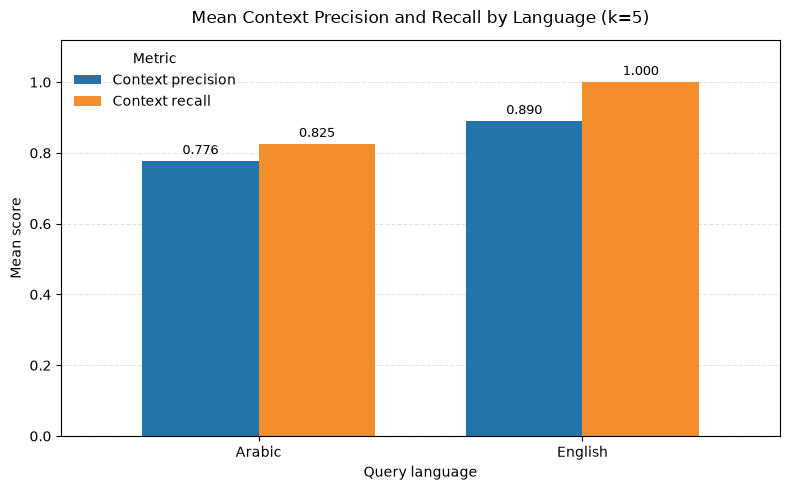

In [16]:
mean_scores = (
    results.groupby("lang")[["precisions", "recalls"]]
    .mean()
    .rename(columns={
        "precisions": "Context precision",
        "recalls": "Context recall",
    })
    .rename(index={"arabic": "Arabic", "english": "English"})
 )

fig, ax = plt.subplots(figsize=(8, 5))
mean_scores.plot(
    kind="bar",
    ax=ax,
    color=["#2374AB", "#F28E2B"],
    width=0.72,
 )

for bars in ax.containers:
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_title("Mean Context Precision and Recall by Language (k=5)", pad=12)
ax.set_xlabel("Query language")
ax.set_ylabel("Mean score")
ax.set_ylim(0, 1.12)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(title="Metric", frameon=False)
ax.tick_params(axis="x", rotation=0)

fig.tight_layout()
fig.savefig("../evaluation/score_results.jpg", dpi=300, bbox_inches="tight")

In [17]:
precisions = []
recalls = []
langs = []
precision_scorer = ContextPrecision(llm=evaluator_llm)
recall_scorer = ContextRecall(llm=evaluator_llm)
for record in tqdm.tqdm(data):
    user_input = record['user_input']
    response = record['response']
    lang = lang_map[detect(user_input)]
    items = await reteriver.search(collection_name=Config().COLLECTION_NAME,
                                 lang=lang , text=user_input,
                                 reterival_renkad_limit=10)
    
    retrieved_contexts = [item.payload['ar_text' if lang == 'arabic' else "text_en"] for item in items ]
    
    try:
        recall_score = await recall_scorer.ascore(
        user_input=user_input,
        retrieved_contexts=retrieved_contexts,
        reference=response
    )
    
        precision_score = await precision_scorer.ascore(
            user_input=user_input,
            retrieved_contexts=retrieved_contexts,
            reference=response
        )
        
        precisions.append(precision_score.value)
        recalls.append(recall_score.value)
        langs.append(lang)
    except Exception as e:
        
        pass
    
   

100%|██████████| 86/86 [2:00:43<00:00, 84.23s/it]   


In [18]:
results = pd.DataFrame(data={"precisions":precisions,
                             "recalls":recalls,
                             "lang":langs})

In [19]:
results.describe()

,precisions,recalls
count,77.000000,77.000000
mean,0.827151,0.974026
std,0.218422,0.138034
min,0.000000,0.000000
25%,0.691667,1.000000
50%,0.916667,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


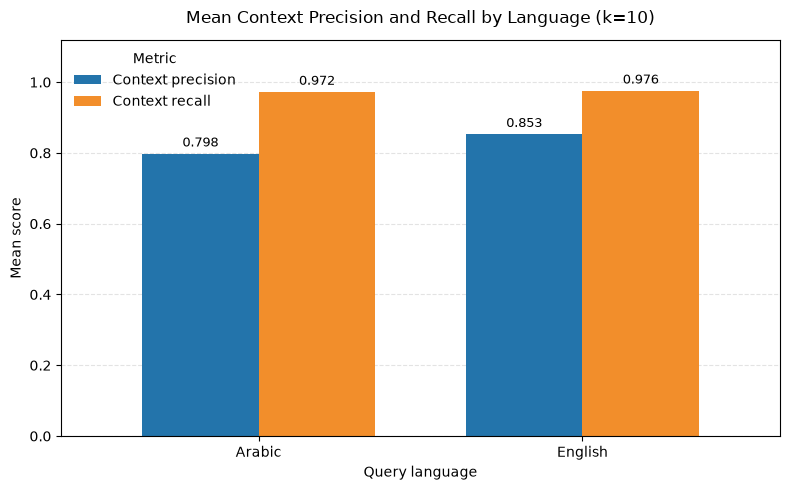

In [20]:
mean_scores = (
    results.groupby("lang")[["precisions", "recalls"]]
    .mean()
    .rename(columns={
        "precisions": "Context precision",
        "recalls": "Context recall",
    })
    .rename(index={"arabic": "Arabic", "english": "English"})
 )

fig, ax = plt.subplots(figsize=(8, 5))
mean_scores.plot(
    kind="bar",
    ax=ax,
    color=["#2374AB", "#F28E2B"],
    width=0.72,
 )

for bars in ax.containers:
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_title("Mean Context Precision and Recall by Language (k=10)", pad=12)
ax.set_xlabel("Query language")
ax.set_ylabel("Mean score")
ax.set_ylim(0, 1.12)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(title="Metric", frameon=False)
ax.tick_params(axis="x", rotation=0)

fig.tight_layout()
fig.savefig("../evaluation/score_results_k10.jpg", dpi=300, bbox_inches="tight")